In [2]:
# librerías para procesar
import numpy  as np
import pandas as pd

# librerías para graficar
import matplotlib.pyplot as plt
import seaborn           as sns
import plotly.express    as px

# Algunos elementos de preprocesamiento: escalamiento y selección de k en k-means
from sklearn.preprocessing     import StandardScaler
from sklearn.metrics           import silhouette_samples, silhouette_score

# Para el algoritmo k-means
from sklearn.cluster           import KMeans

# Para otros algoritmos de machine learning
from sklearn.decomposition     import PCA
from sklearn.neighbors         import KNeighborsClassifier
from sklearn.neighbors         import NearestNeighbors
from sklearn.metrics           import pairwise_distances_argmin_min

#Para omitir los warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
#Dataset cargado

In [4]:
import kagglehub
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")

100%|██████████| 1.55k/1.55k [00:00<00:00, 3.43MB/s]

Extracting files...


In [5]:
segmentation_df = pd.read_csv(path + "/Mall_Customers.csv")
segmentation_df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
print(segmentation_df.shape)
print(segmentation_df.info())
print(segmentation_df.describe())

(200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.0

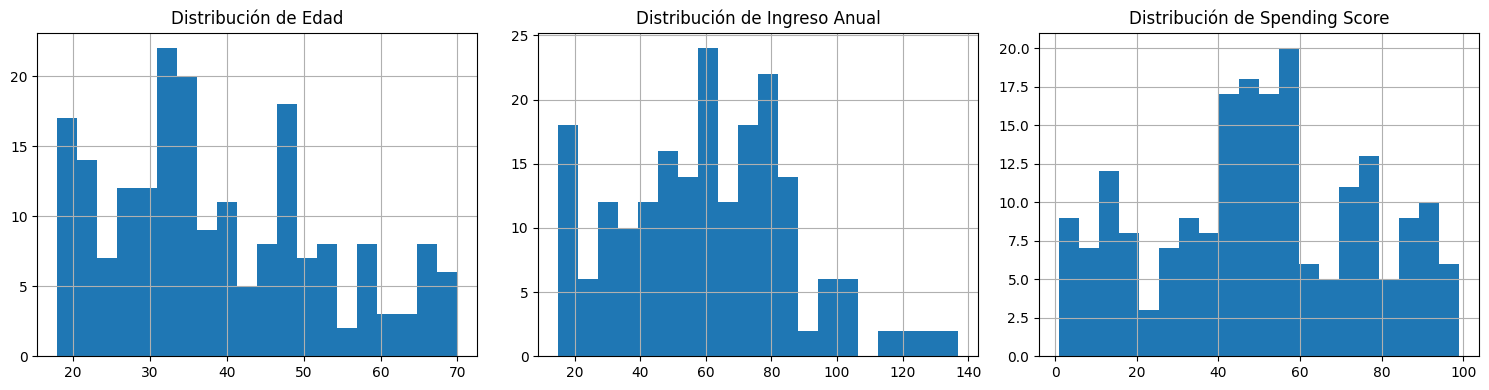

In [7]:
#Graficamos distribución variables
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
segmentation_df['Age'].hist(bins=20, ax=axes[0])
axes[0].set_title('Distribución de Edad')
segmentation_df['Annual Income (k$)'].hist(bins=20, ax=axes[1])
axes[1].set_title('Distribución de Ingreso Anual')
segmentation_df['Spending Score (1-100)'].hist(bins=20, ax=axes[2])
axes[2].set_title('Distribución de Spending Score')
plt.tight_layout()
plt.show()

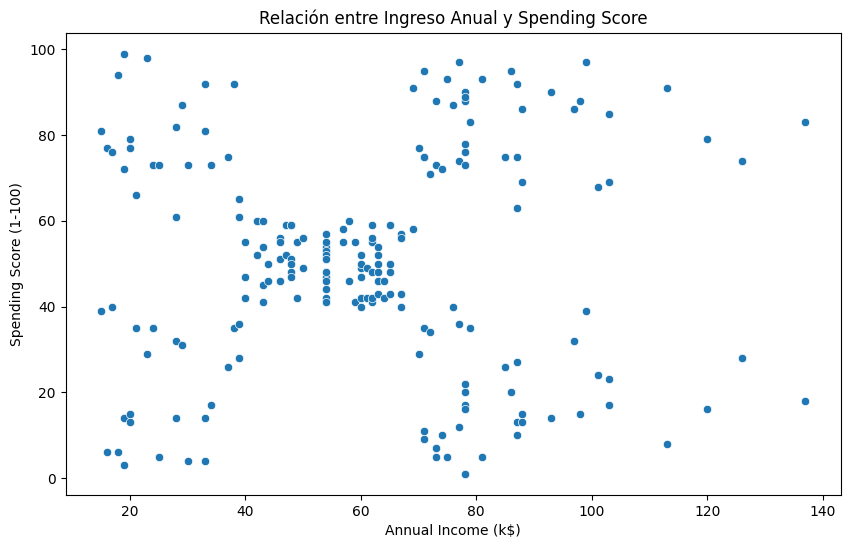

In [8]:
#Graficamos relación entre las variables
#Ingreso anual vs spending score
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=segmentation_df)
plt.title('Relación entre Ingreso Anual y Spending Score')
plt.show()

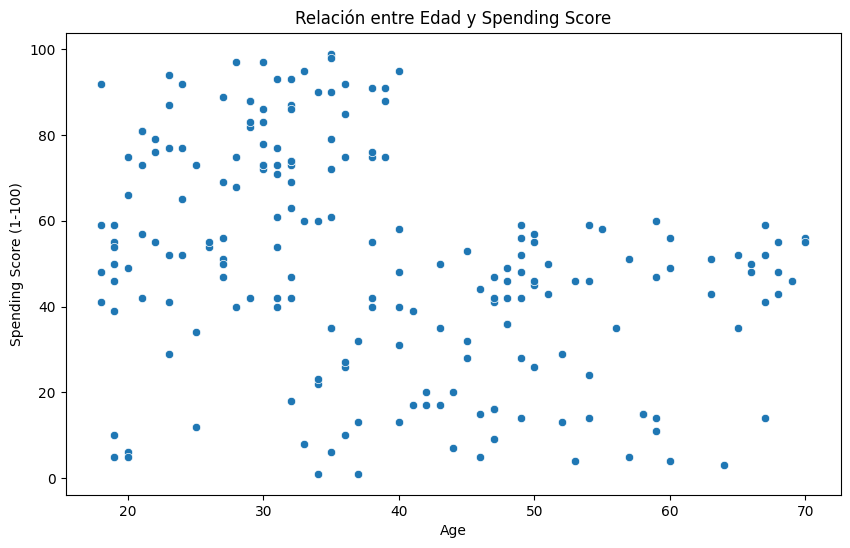

In [9]:
#Edad vs spending score
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Spending Score (1-100)', data=segmentation_df)
plt.title('Relación entre Edad y Spending Score')
plt.show()

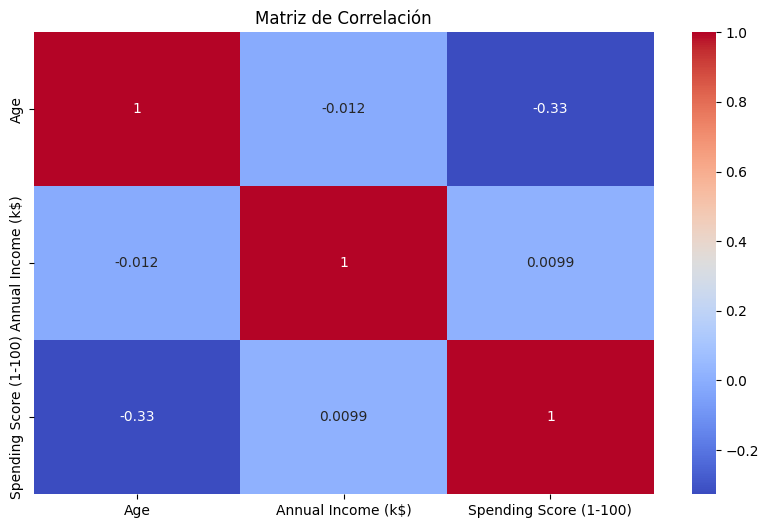

In [10]:
#Matriz de correlación
plt.figure(figsize=(10, 6))
sns.heatmap(segmentation_df.drop(columns=['Gender', 'CustomerID']).corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

In [11]:
#Selección de features

In [12]:
# Seleccionamos Annual Income y Spending Score
# porque son las variables más utilizadas para segmentación
# comercial y permiten visualizar fácilmente los clusters.
features = ['Annual Income (k$)', 'Spending Score (1-100)']
X = segmentation_df[features]
#Escalamos los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
#Método del codo

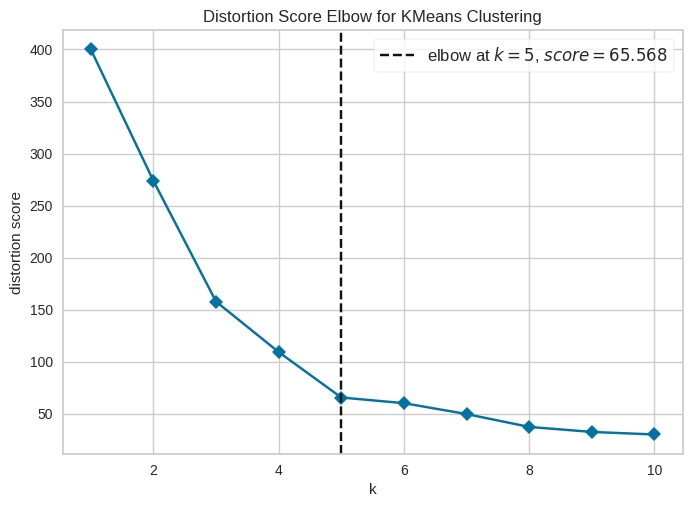

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [30]:
from yellowbrick.cluster import KElbowVisualizer
model = KMeans(random_state=42)
visualizer = KElbowVisualizer(model, k=(1,11), timings=False)
visualizer.fit(X_scaled)
visualizer.show(show = False)

El método del codo muestra una reducción significativa de la inercia hasta k=5, a partir de donde la mejora marginal disminuye. Adicionalmente, el análisis de silueta alcanza uno de sus valores más altos en k=5, por lo que se selecciona este número de clusters como compromiso entre separación e interpretabilidad.

In [31]:
#Método de la silueta

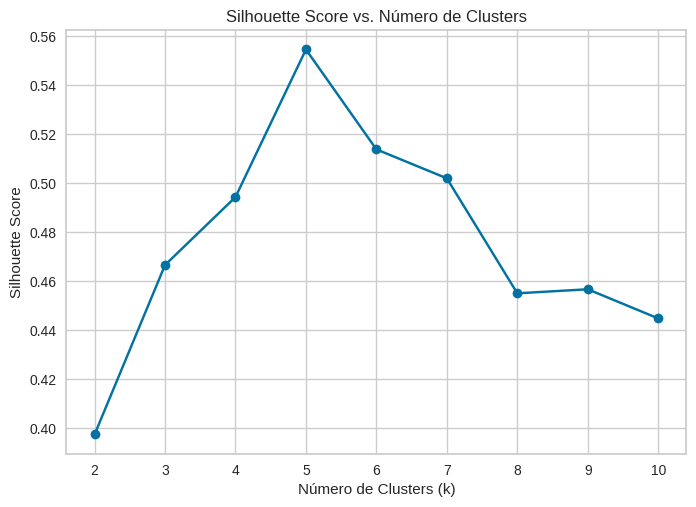

In [33]:
#Generación modelos para diferentes $K$
models = [KMeans(n_clusters=k, random_state=42).fit(X_scaled) for k in range(2, 11)]
silueta_scores = [silhouette_score(X_scaled, model.labels_) for model in models]

# gráficamos los valores de la silueta para cada valor de k
plt.plot(range(2, 11), silueta_scores, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Número de Clusters')
plt.show()

Según el gráfico anterior podemos usar k=5. Representando incremento del coeficiente de la silueta.

In [34]:
#K-Means aplicado con k = 5
n = 5
kmeans = KMeans(n_clusters=n, random_state=42)
segmentation_df['Cluster'] = kmeans.fit_predict(X_scaled)

In [15]:
#Visualización de clusters

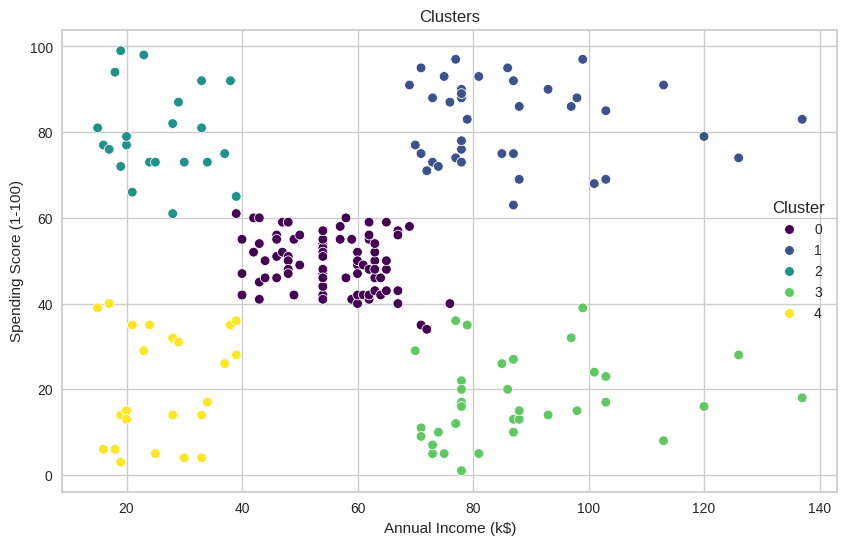

In [38]:
#Grafico de clusters scatter
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=segmentation_df, palette='viridis')
plt.title('Clusters')
plt.show()

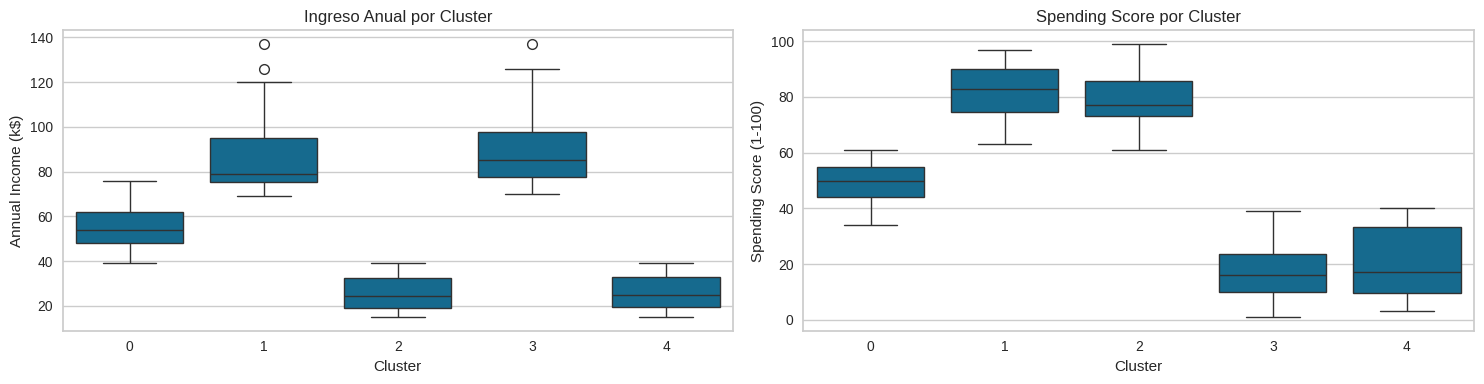

In [35]:
#Boxplots para 5 clusters
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(x='Cluster', y='Annual Income (k$)', data=segmentation_df, ax=axes[0])
axes[0].set_title('Ingreso Anual por Cluster')
sns.boxplot(x='Cluster', y='Spending Score (1-100)', data=segmentation_df, ax=axes[1])
axes[1].set_title('Spending Score por Cluster')
plt.tight_layout()
plt.show()

In [16]:
#Perfil de clusters

Silhouette promedio: 0.5546571631111091


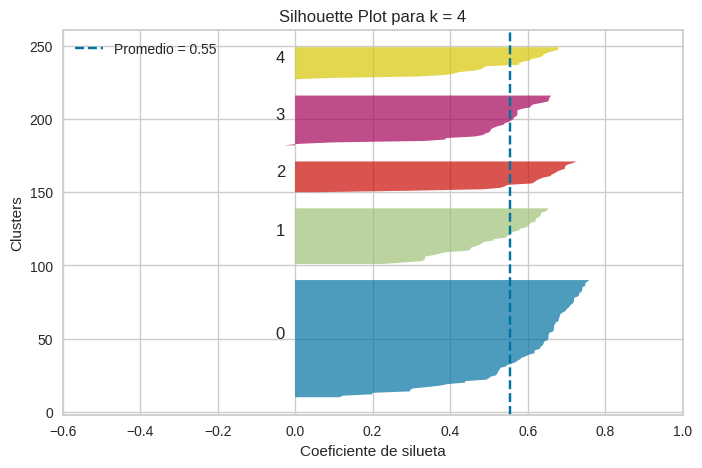

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_samples, silhouette_score

labels = kmeans.labels_

silhouette_avg = silhouette_score(X_scaled, labels)
print("Silhouette promedio:", silhouette_avg)

sample_silhouette_values = silhouette_samples(X_scaled, labels)

k = len(np.unique(labels))

fig, ax = plt.subplots(figsize=(8, 5))

y_lower = 10

for i in range(k):
    ith_cluster_values = sample_silhouette_values[labels == i]
    ith_cluster_values.sort()

    size_cluster_i = ith_cluster_values.shape[0]
    y_upper = y_lower + size_cluster_i

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_values,
        alpha=0.7
    )

    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    y_lower = y_upper + 10

ax.axvline(
    x=silhouette_avg,
    linestyle="--",
    label=f"Promedio = {silhouette_avg:.2f}"
)

ax.set_title("Silhouette Plot para k = 4")
ax.set_xlabel("Coeficiente de silueta")
ax.set_ylabel("Clusters")
ax.set_xlim([-0.6, 1])
ax.legend()

plt.show()

In [41]:
cluster_profiles = segmentation_df.groupby('Cluster').mean(numeric_only = True)
cluster_profiles

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,86.320988,42.716049,55.296296,49.518519
1,162.000000,32.692308,86.538462,82.128205
2,23.090909,25.272727,25.727273,79.363636
3,164.371429,41.114286,88.200000,17.114286
4,23.000000,45.217391,26.304348,20.913043




*   Cluster 0 Perfil: Promedio - Cliente típico, equilibrio entre ingreso y gasto.
*   Cluster 1 Perfil: Premium - Jóvenes con alto ingreso y alto gasto (mejor segmento).

*   Cluster 2 Perfil: Gastadores jóvenes - Bajos ingresos pero gastan mucho (posiblemente estudiantes o con apoyo familiar).
*   Cluster 3 Perfil: Ahorradores - Altos ingresos pero no gastan (potencial para campañas de fidelización).
*   Cluster 4 Perfil: Conservadores - Bajos ingresos y bajo gasto (clientes de bajo valor).







In [17]:
#Estrategias por cluster

In [47]:
# Estrategias por cluster (basado en los datos reales)
strategies = {
    0: "🔵 **Clientes Promedio** (Ingreso: $55.3k, Gasto: 49.5, Edad: 42.7) → *Programas de fidelización y retención. Cross-selling para aumentar ticket promedio.*",

    1: "🟢 **Clientes Premium** (Ingreso: $86.5k, Gasto: 82.1, Edad: 32.7) → *Experiencias VIP, up-selling de productos de gama alta. Customer success y retención de alto valor.*",

    2: "🟡 **Jóvenes Gastadores** (Ingreso: $25.7k, Gasto: 79.4, Edad: 25.3) → *Gamificación, promociones en redes sociales, marketing digital. Incentivar lealtad con recompensas atractivas.*",

    3: "🔴 **Ahorradores de Alto Ingreso** (Ingreso: $88.2k, Gasto: 17.1, Edad: 41.1) → *Educación financiera, incentivos para gastar (descuentos en productos de alto valor), planes de pago flexibles.*",

    4: "🟣 **Clientes Conservadores** (Ingreso: $26.3k, Gasto: 20.9, Edad: 45.2) → *Productos de bajo costo, educación financiera, retención a largo plazo con beneficios acumulativos.*"
}

print("\n💡 ESTRATEGIAS POR CLUSTER:")
print("="*70)
for cluster, strategy in strategies.items():
    print(f"\nCluster {cluster}: {strategy}")
print("\n" + "="*70)


💡 ESTRATEGIAS POR CLUSTER:

Cluster 0: 🔵 **Clientes Promedio** (Ingreso: $55.3k, Gasto: 49.5, Edad: 42.7) → *Programas de fidelización y retención. Cross-selling para aumentar ticket promedio.*

Cluster 1: 🟢 **Clientes Premium** (Ingreso: $86.5k, Gasto: 82.1, Edad: 32.7) → *Experiencias VIP, up-selling de productos de gama alta. Customer success y retención de alto valor.*

Cluster 2: 🟡 **Jóvenes Gastadores** (Ingreso: $25.7k, Gasto: 79.4, Edad: 25.3) → *Gamificación, promociones en redes sociales, marketing digital. Incentivar lealtad con recompensas atractivas.*

Cluster 3: 🔴 **Ahorradores de Alto Ingreso** (Ingreso: $88.2k, Gasto: 17.1, Edad: 41.1) → *Educación financiera, incentivos para gastar (descuentos en productos de alto valor), planes de pago flexibles.*

Cluster 4: 🟣 **Clientes Conservadores** (Ingreso: $26.3k, Gasto: 20.9, Edad: 45.2) → *Productos de bajo costo, educación financiera, retención a largo plazo con beneficios acumulativos.*

